# 03 - EDA Temporal para Forecasting

## Objetivo
Analizar en profundidad los patrones temporales de las ventas de DSMarket para entender tendencias, estacionalidad, autocorrelación y el efecto de variables externas. Este análisis guiará las decisiones de feature engineering y selección de modelos.

## Contexto de negocio
Para predecir ventas a 28 días, necesitamos entender:
- ¿Las ventas tienen tendencia creciente o decreciente?
- ¿Qué patrones estacionales existen (semanal, mensual, anual)?
- ¿Cuántos días de historia son relevantes para predecir el futuro?
- ¿Cómo afectan los eventos, días de la semana y precios a las ventas?
- ¿Los patrones son similares entre categorías, regiones y tiendas?

## Qué se consigue al finalizar
- Comprensión de los componentes de la serie temporal (tendencia, estacionalidad, ruido)
- Identificación de lags relevantes para el modelo
- Cuantificación del efecto de variables externas
- Detección de anomalías y fechas atípicas
- Recomendaciones concretas para feature engineering y modelado

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import warnings

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
warnings.filterwarnings('ignore')

# Configuración de figuras
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## 1. Carga de datos procesados

In [2]:
# Cargar dataset procesado
df = pd.read_csv('/Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/data_dsmarket/processed/sales_processed.csv')

# Convertir date a datetime
df['date'] = pd.to_datetime(df['date'])

print(f"Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Rango de fechas: {df['date'].min()} a {df['date'].max()}")
print(f"Series únicas (id): {df['id'].nunique():,}")

Dataset cargado: 58,327,370 filas x 17 columnas
Rango de fechas: 2011-01-29 00:00:00 a 2016-04-24 00:00:00
Series únicas (id): 30,490


## 2. Preparación de series agregadas

Para el análisis temporal, trabajaremos con series agregadas a distintos niveles:
- **Total diario**: suma de todas las ventas por día
- **Por región**: ventas diarias por región
- **Por categoría**: ventas diarias por categoría
- **Por tienda**: ventas diarias por tienda

Esto nos permite analizar patrones globales y segmentados sin el ruido de series individuales.

In [3]:
# Serie total diaria
ventas_diarias = df.groupby('date')['sales'].sum().reset_index()
ventas_diarias.columns = ['date', 'sales']
ventas_diarias = ventas_diarias.sort_values('date').reset_index(drop=True)

print(f"Serie total diaria: {len(ventas_diarias)} días")
print(f"Ventas promedio diarias: {ventas_diarias['sales'].mean():,.0f} unidades")
ventas_diarias.head()

Serie total diaria: 1913 días
Ventas promedio diarias: 34,342 unidades


,date,sales
0,2011-01-29,32631
1,2011-01-30,31749
2,2011-01-31,23783
3,2011-02-01,25412
4,2011-02-02,19146


In [4]:
# Serie por región
ventas_region = df.groupby(['date', 'region'])['sales'].sum().reset_index()
ventas_region = ventas_region.sort_values(['region', 'date']).reset_index(drop=True)

print(f"Serie por región: {len(ventas_region)} filas")
print(f"Regiones: {ventas_region['region'].unique()}")

Serie por región: 5739 filas
Regiones: ['Boston' 'New York' 'Philadelphia']


In [5]:
# Serie por categoría
ventas_categoria = df.groupby(['date', 'category'])['sales'].sum().reset_index()
ventas_categoria = ventas_categoria.sort_values(['category', 'date']).reset_index(drop=True)

print(f"Serie por categoría: {len(ventas_categoria)} filas")
print(f"Categorías: {ventas_categoria['category'].unique()}")

Serie por categoría: 5739 filas
Categorías: ['ACCESORIES' 'HOME_&_GARDEN' 'SUPERMARKET']


In [6]:
# Serie por tienda
ventas_tienda = df.groupby(['date', 'store'])['sales'].sum().reset_index()
ventas_tienda = ventas_tienda.sort_values(['store', 'date']).reset_index(drop=True)

print(f"Serie por tienda: {len(ventas_tienda)} filas")
print(f"Tiendas: {ventas_tienda['store'].unique()}")

Serie por tienda: 19130 filas
Tiendas: ['Back_Bay' 'Brooklyn' 'Greenwich_Village' 'Harlem' 'Midtown_Village'
 'Queen_Village' 'Roxbury' 'South_End' 'Tribeca' 'Yorktown']


In [7]:
# Añadir variables temporales a la serie diaria para análisis
ventas_diarias['year'] = ventas_diarias['date'].dt.year
ventas_diarias['month'] = ventas_diarias['date'].dt.month
ventas_diarias['week'] = ventas_diarias['date'].dt.isocalendar().week.astype(int)
ventas_diarias['dayofweek'] = ventas_diarias['date'].dt.dayofweek  # 0=lunes, 6=domingo
ventas_diarias['dayofweek_name'] = ventas_diarias['date'].dt.day_name()
ventas_diarias['quarter'] = ventas_diarias['date'].dt.quarter

print("Variables temporales añadidas a ventas_diarias")
ventas_diarias.head()

Variables temporales añadidas a ventas_diarias


,date,sales,year,month,week,dayofweek,dayofweek_name,quarter
0,2011-01-29,32631,2011,1,4,5,Saturday,1
1,2011-01-30,31749,2011,1,4,6,Sunday,1
2,2011-01-31,23783,2011,1,5,0,Monday,1
3,2011-02-01,25412,2011,2,5,1,Tuesday,1
4,2011-02-02,19146,2011,2,5,2,Wednesday,1


## 3. Análisis de tendencia

Analizamos si las ventas tienen una tendencia global (creciente, decreciente o estable) a lo largo del tiempo.

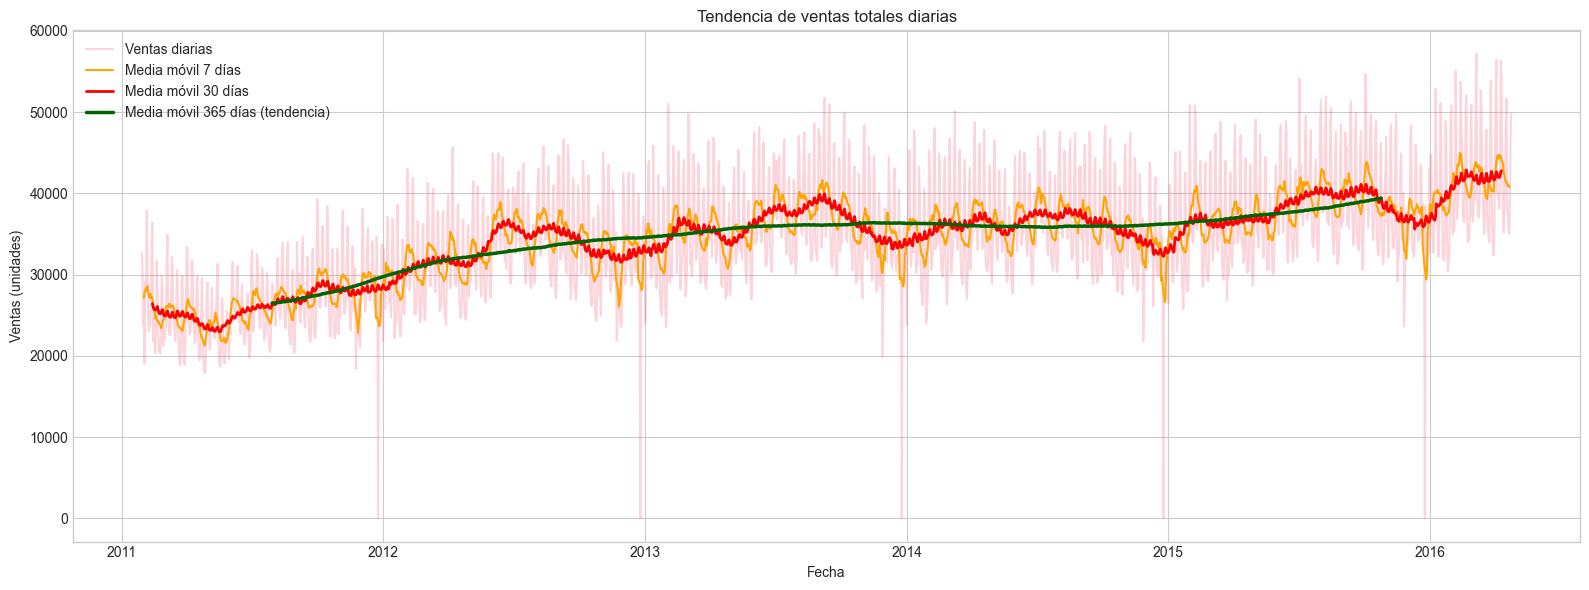

In [8]:
# Tendencia global con media móvil
fig, ax = plt.subplots(figsize=(16, 6))

# Ventas diarias
ax.plot(ventas_diarias['date'], ventas_diarias['sales'], alpha=0.3, label='Ventas diarias')

# Media móvil de 7 días (semanal)
ventas_diarias['ma_7'] = ventas_diarias['sales'].rolling(window=7, center=True).mean()
ax.plot(ventas_diarias['date'], ventas_diarias['ma_7'], color='orange', linewidth=1.5, label='Media móvil 7 días')

# Media móvil de 30 días (mensual)
ventas_diarias['ma_30'] = ventas_diarias['sales'].rolling(window=30, center=True).mean()
ax.plot(ventas_diarias['date'], ventas_diarias['ma_30'], color='red', linewidth=2, label='Media móvil 30 días')

# Media móvil de 365 días (anual) - para ver tendencia
ventas_diarias['ma_365'] = ventas_diarias['sales'].rolling(window=365, center=True).mean()
ax.plot(ventas_diarias['date'], ventas_diarias['ma_365'], color='darkgreen', linewidth=2.5, label='Media móvil 365 días (tendencia)')

ax.set_xlabel('Fecha')
ax.set_ylabel('Ventas (unidades)')
ax.set_title('Tendencia de ventas totales diarias')
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# Cuantificar tendencia: comparar años
print("="*60)
print("VENTAS PROMEDIO POR AÑO")
print("="*60)

ventas_por_año = ventas_diarias.groupby('year')['sales'].agg(['mean', 'std', 'min', 'max', 'sum'])
ventas_por_año['dias'] = ventas_diarias.groupby('year')['sales'].count()
ventas_por_año['crecimiento_%'] = ventas_por_año['mean'].pct_change() * 100

print(ventas_por_año)

VENTAS PROMEDIO POR AÑO
         mean     std    min    max       sum  dias  crecimiento_%
year                                                              
2011 26280.67 4769.10     13  39312   8856585   337            NaN
2012 32955.84 5953.10     11  46649  12061837   366          25.40
2013 35988.36 6280.27     20  51740  13135753   365           9.20
2014 35862.40 6096.62     20  50090  13089776   365          -0.35
2015 37810.44 6403.08     14  54687  13800811   365           5.43
2016 41309.97 6868.19  30446  57218   4750647   115           9.26


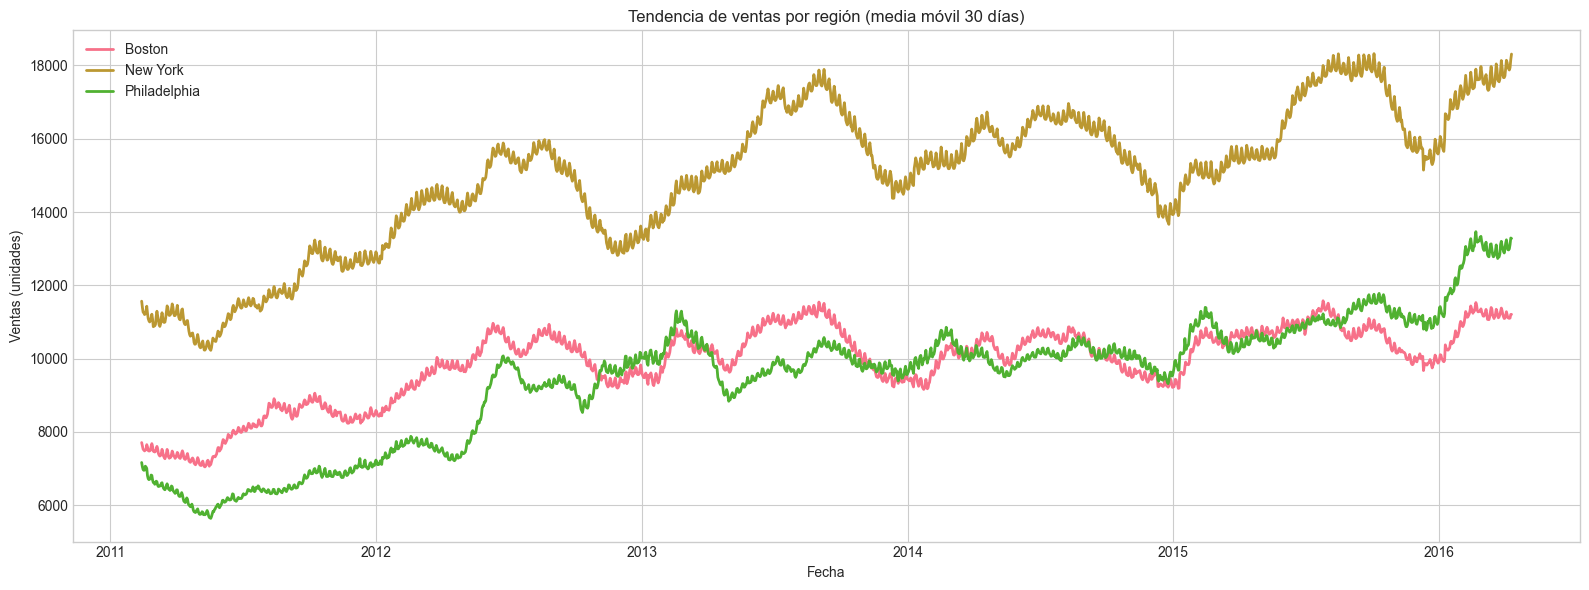

In [10]:
# Tendencia por región
fig, ax = plt.subplots(figsize=(16, 6))

for region in ventas_region['region'].unique():
    data = ventas_region[ventas_region['region'] == region].copy()
    data['ma_30'] = data['sales'].rolling(window=30, center=True).mean()
    ax.plot(data['date'], data['ma_30'], linewidth=2, label=region)

ax.set_xlabel('Fecha')
ax.set_ylabel('Ventas (unidades)')
ax.set_title('Tendencia de ventas por región (media móvil 30 días)')
ax.legend()
plt.tight_layout()
plt.show()

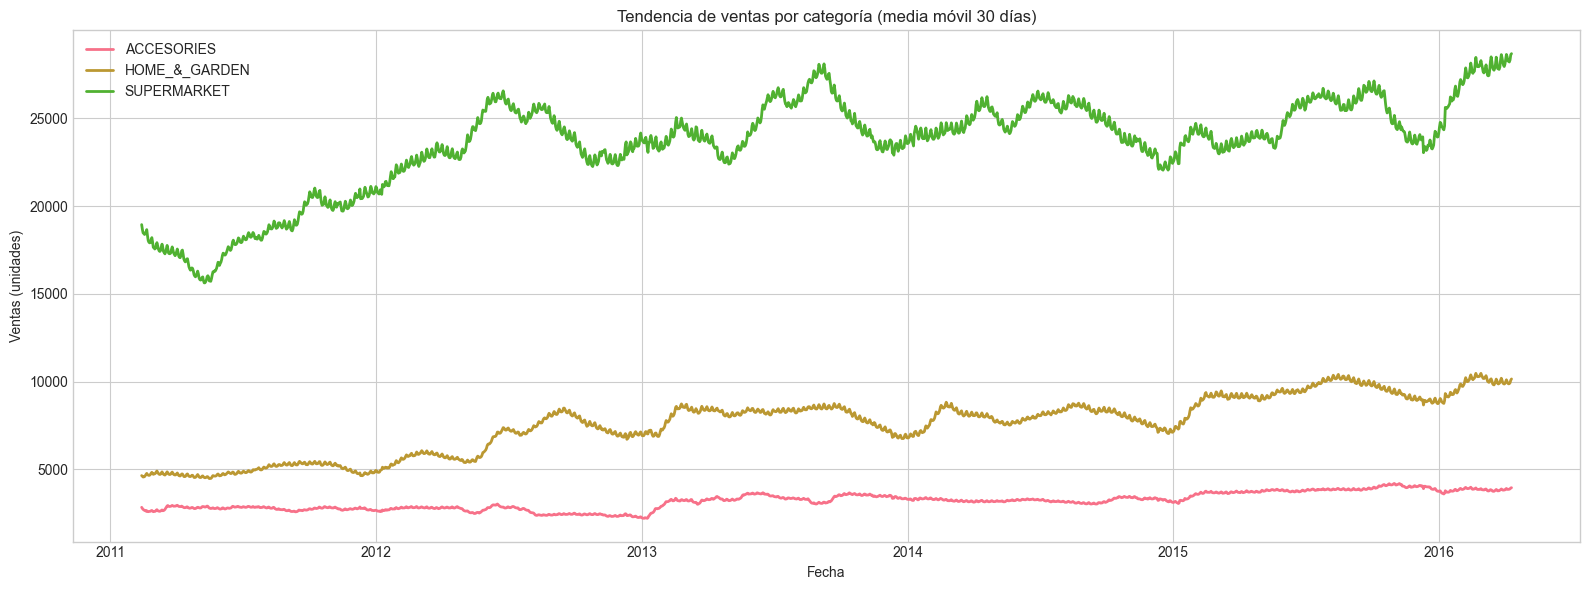

In [11]:
# Tendencia por categoría
fig, ax = plt.subplots(figsize=(16, 6))

for categoria in ventas_categoria['category'].unique():
    data = ventas_categoria[ventas_categoria['category'] == categoria].copy()
    data['ma_30'] = data['sales'].rolling(window=30, center=True).mean()
    ax.plot(data['date'], data['ma_30'], linewidth=2, label=categoria)

ax.set_xlabel('Fecha')
ax.set_ylabel('Ventas (unidades)')
ax.set_title('Tendencia de ventas por categoría (media móvil 30 días)')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Análisis de estacionalidad

Analizamos patrones que se repiten de forma regular:
- **Estacionalidad semanal**: diferencias entre días de la semana
- **Estacionalidad mensual**: diferencias entre meses del año
- **Estacionalidad anual**: patrones que se repiten cada año

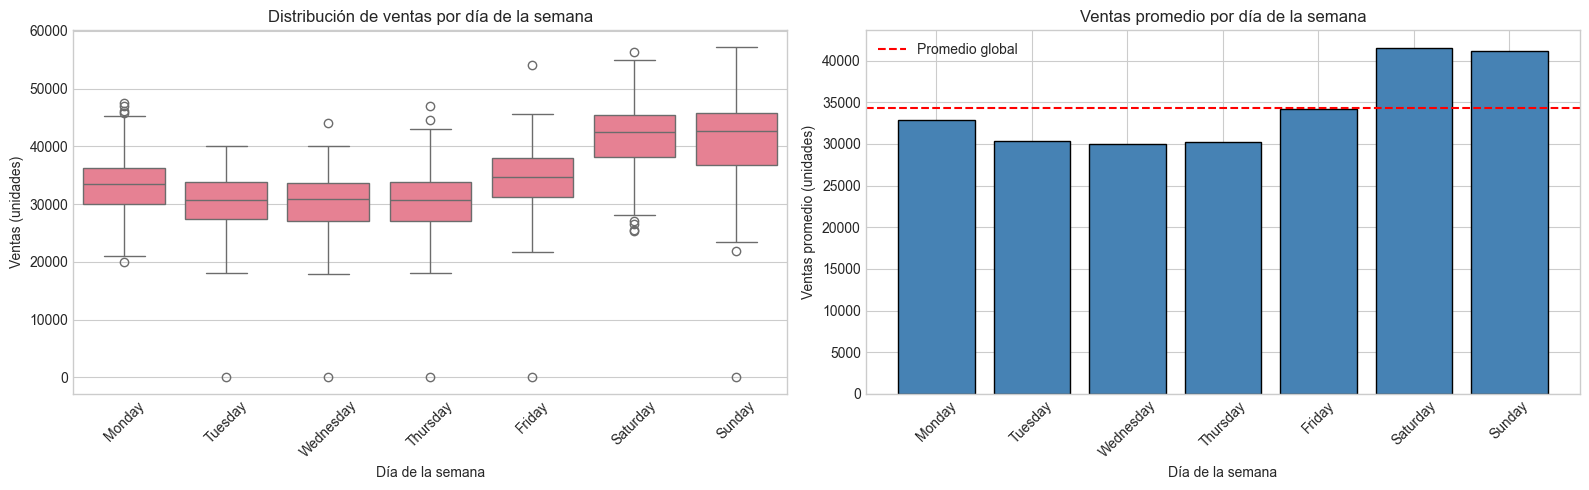

VENTAS PROMEDIO POR DÍA DE LA SEMANA
dayofweek_name
Monday      32853.00
Tuesday     30369.00
Wednesday   30010.00
Thursday    30205.00
Friday      34226.00
Saturday    41547.00
Sunday      41130.00
Name: sales, dtype: float64

Día con más ventas: Saturday (41,547)
Día con menos ventas: Wednesday (30,010)
Diferencia: 38.4%


In [12]:
# Estacionalidad semanal: ventas promedio por día de la semana
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Orden de días
dias_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Boxplot
ventas_diarias['dayofweek_name'] = pd.Categorical(ventas_diarias['dayofweek_name'], categories=dias_orden, ordered=True)
ventas_diarias_sorted = ventas_diarias.sort_values('dayofweek_name')

sns.boxplot(data=ventas_diarias_sorted, x='dayofweek_name', y='sales', ax=axes[0])
axes[0].set_xlabel('Día de la semana')
axes[0].set_ylabel('Ventas (unidades)')
axes[0].set_title('Distribución de ventas por día de la semana')
axes[0].tick_params(axis='x', rotation=45)

# Barplot con promedio
ventas_por_dia = ventas_diarias.groupby('dayofweek_name')['sales'].mean().reindex(dias_orden)
axes[1].bar(ventas_por_dia.index, ventas_por_dia.values, color='steelblue', edgecolor='black')
axes[1].axhline(y=ventas_diarias['sales'].mean(), color='red', linestyle='--', label='Promedio global')
axes[1].set_xlabel('Día de la semana')
axes[1].set_ylabel('Ventas promedio (unidades)')
axes[1].set_title('Ventas promedio por día de la semana')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

# Estadísticas
print("="*60)
print("VENTAS PROMEDIO POR DÍA DE LA SEMANA")
print("="*60)
print(ventas_por_dia.round(0))
print(f"\nDía con más ventas: {ventas_por_dia.idxmax()} ({ventas_por_dia.max():,.0f})")
print(f"Día con menos ventas: {ventas_por_dia.idxmin()} ({ventas_por_dia.min():,.0f})")
print(f"Diferencia: {((ventas_por_dia.max() / ventas_por_dia.min()) - 1) * 100:.1f}%")

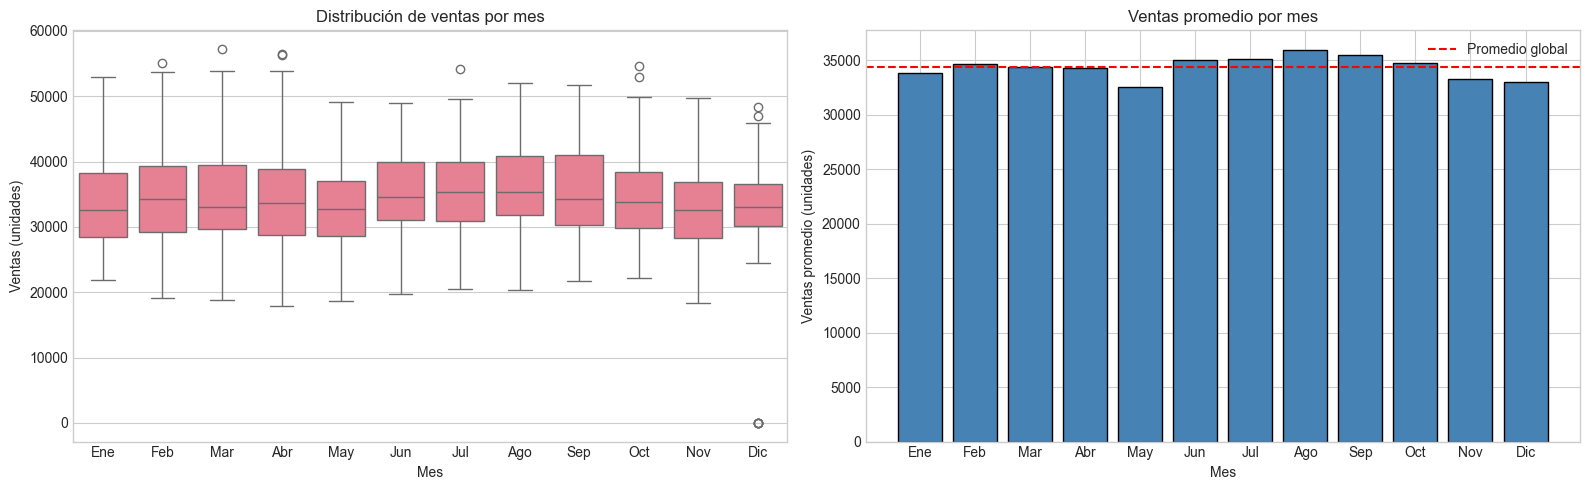

VENTAS PROMEDIO POR MES
Ene: 33,832
Feb: 34,645
Mar: 34,340
Abr: 34,259
May: 32,504
Jun: 35,001
Jul: 35,122
Ago: 35,947
Sep: 35,479
Oct: 34,713
Nov: 33,291
Dic: 32,980

Mes con más ventas: Ago (35,947)
Mes con menos ventas: May (32,504)


In [13]:
# Estacionalidad mensual: ventas promedio por mes
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Nombres de meses
meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

# Boxplot
sns.boxplot(data=ventas_diarias, x='month', y='sales', ax=axes[0])
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Ventas (unidades)')
axes[0].set_title('Distribución de ventas por mes')
axes[0].set_xticklabels(meses)

# Barplot con promedio
ventas_por_mes = ventas_diarias.groupby('month')['sales'].mean()
axes[1].bar(ventas_por_mes.index, ventas_por_mes.values, color='steelblue', edgecolor='black')
axes[1].axhline(y=ventas_diarias['sales'].mean(), color='red', linestyle='--', label='Promedio global')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Ventas promedio (unidades)')
axes[1].set_title('Ventas promedio por mes')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(meses)
axes[1].legend()

plt.tight_layout()
plt.show()

# Estadísticas
print("="*60)
print("VENTAS PROMEDIO POR MES")
print("="*60)
for i, mes in enumerate(meses, 1):
    print(f"{mes}: {ventas_por_mes[i]:,.0f}")
print(f"\nMes con más ventas: {meses[ventas_por_mes.idxmax()-1]} ({ventas_por_mes.max():,.0f})")
print(f"Mes con menos ventas: {meses[ventas_por_mes.idxmin()-1]} ({ventas_por_mes.min():,.0f})")

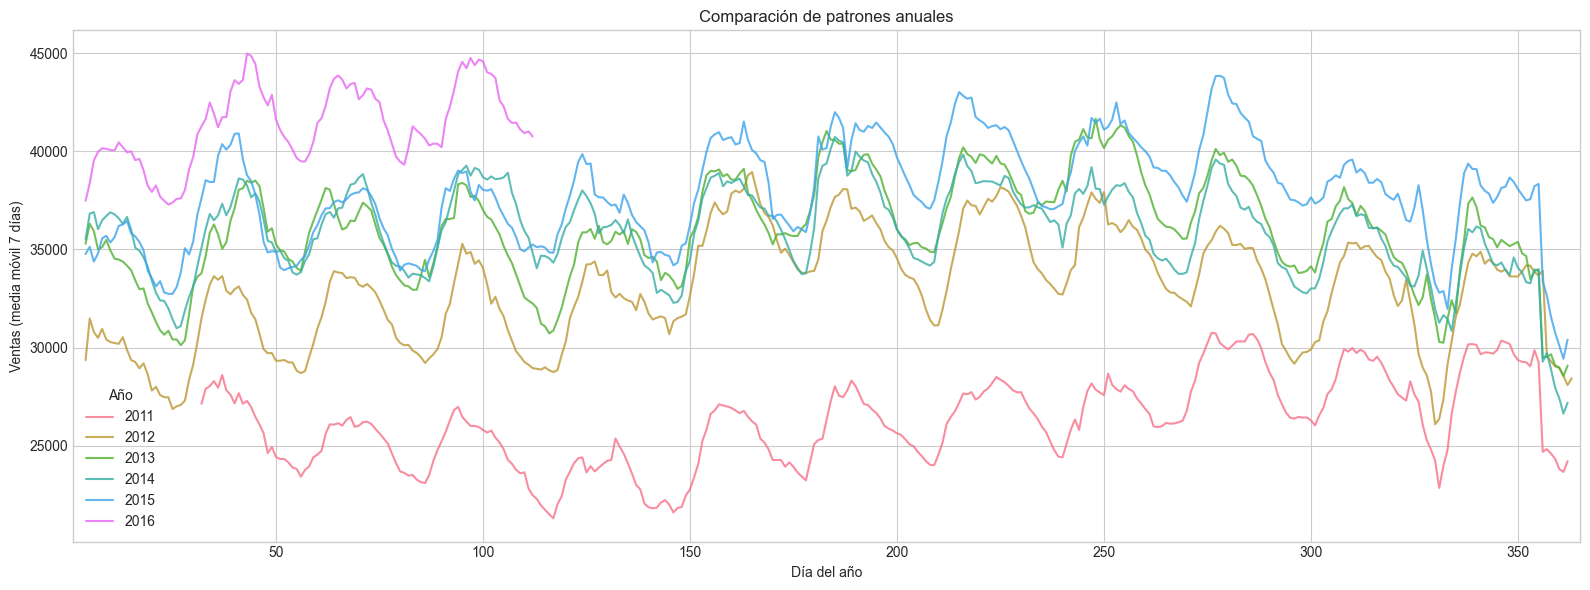

In [14]:
# Estacionalidad anual: comparar el mismo período entre años
fig, ax = plt.subplots(figsize=(16, 6))

# Crear columna de día del año
ventas_diarias['dayofyear'] = ventas_diarias['date'].dt.dayofyear

for year in sorted(ventas_diarias['year'].unique()):
    data = ventas_diarias[ventas_diarias['year'] == year]
    # Media móvil de 7 días para suavizar
    sales_smooth = data['sales'].rolling(window=7, center=True).mean()
    ax.plot(data['dayofyear'], sales_smooth, label=str(year), alpha=0.8)

ax.set_xlabel('Día del año')
ax.set_ylabel('Ventas (media móvil 7 días)')
ax.set_title('Comparación de patrones anuales')
ax.legend(title='Año')
ax.set_xlim(1, 365)
plt.tight_layout()
plt.show()

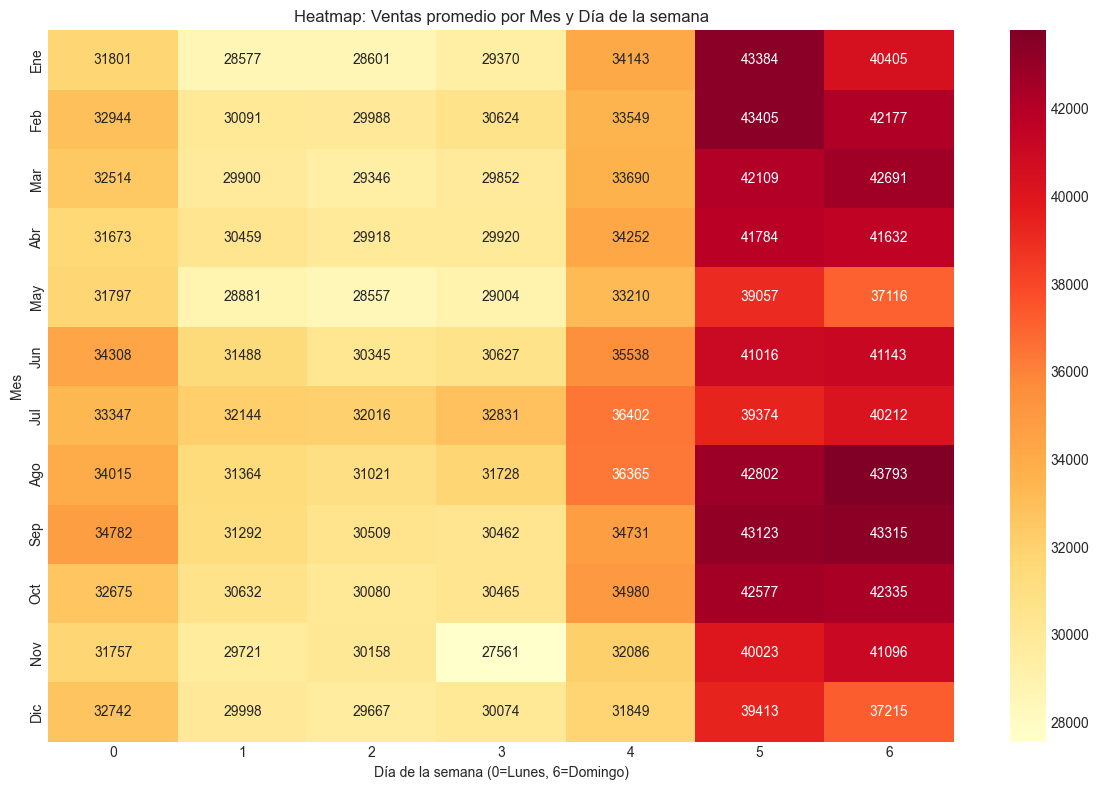

In [15]:
# Heatmap: mes vs día de la semana
pivot_mes_dia = ventas_diarias.groupby(['month', 'dayofweek'])['sales'].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot_mes_dia, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax)
ax.set_xlabel('Día de la semana (0=Lunes, 6=Domingo)')
ax.set_ylabel('Mes')
ax.set_yticklabels(meses)
ax.set_title('Heatmap: Ventas promedio por Mes y Día de la semana')
plt.tight_layout()
plt.show()

## 5. Descomposición de series temporales

Descomponemos la serie de ventas en sus componentes:
- **Tendencia**: dirección general a largo plazo
- **Estacionalidad**: patrones que se repiten regularmente
- **Residuo**: variación no explicada por tendencia ni estacionalidad

Usamos descomposición aditiva: `Y = Tendencia + Estacionalidad + Residuo`

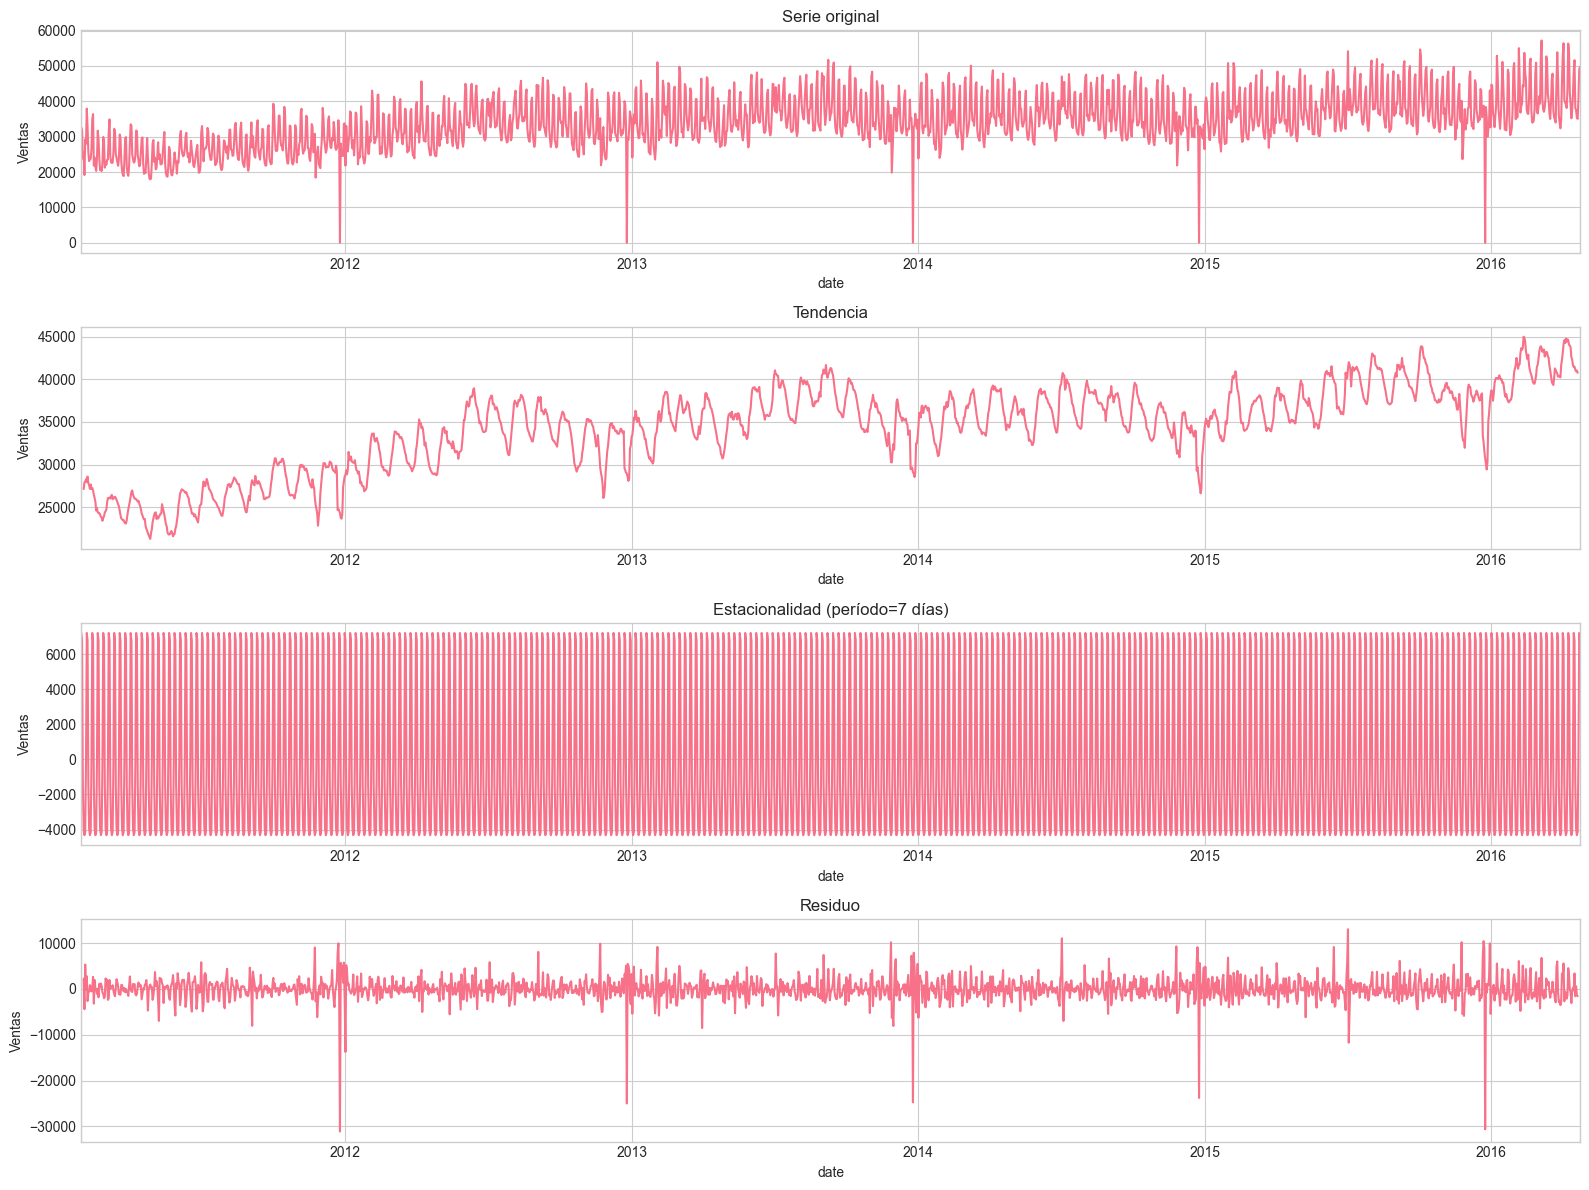

In [16]:
# Descomposición de la serie total diaria
# Usamos período de 7 días (estacionalidad semanal)

# Crear serie temporal indexada por fecha
serie_temporal = ventas_diarias.set_index('date')['sales']

# Descomposición con período semanal
decomposition_semanal = seasonal_decompose(serie_temporal, model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(16, 12))

decomposition_semanal.observed.plot(ax=axes[0], title='Serie original')
axes[0].set_ylabel('Ventas')

decomposition_semanal.trend.plot(ax=axes[1], title='Tendencia')
axes[1].set_ylabel('Ventas')

decomposition_semanal.seasonal.plot(ax=axes[2], title='Estacionalidad (período=7 días)')
axes[2].set_ylabel('Ventas')

decomposition_semanal.resid.plot(ax=axes[3], title='Residuo')
axes[3].set_ylabel('Ventas')

plt.tight_layout()
plt.show()

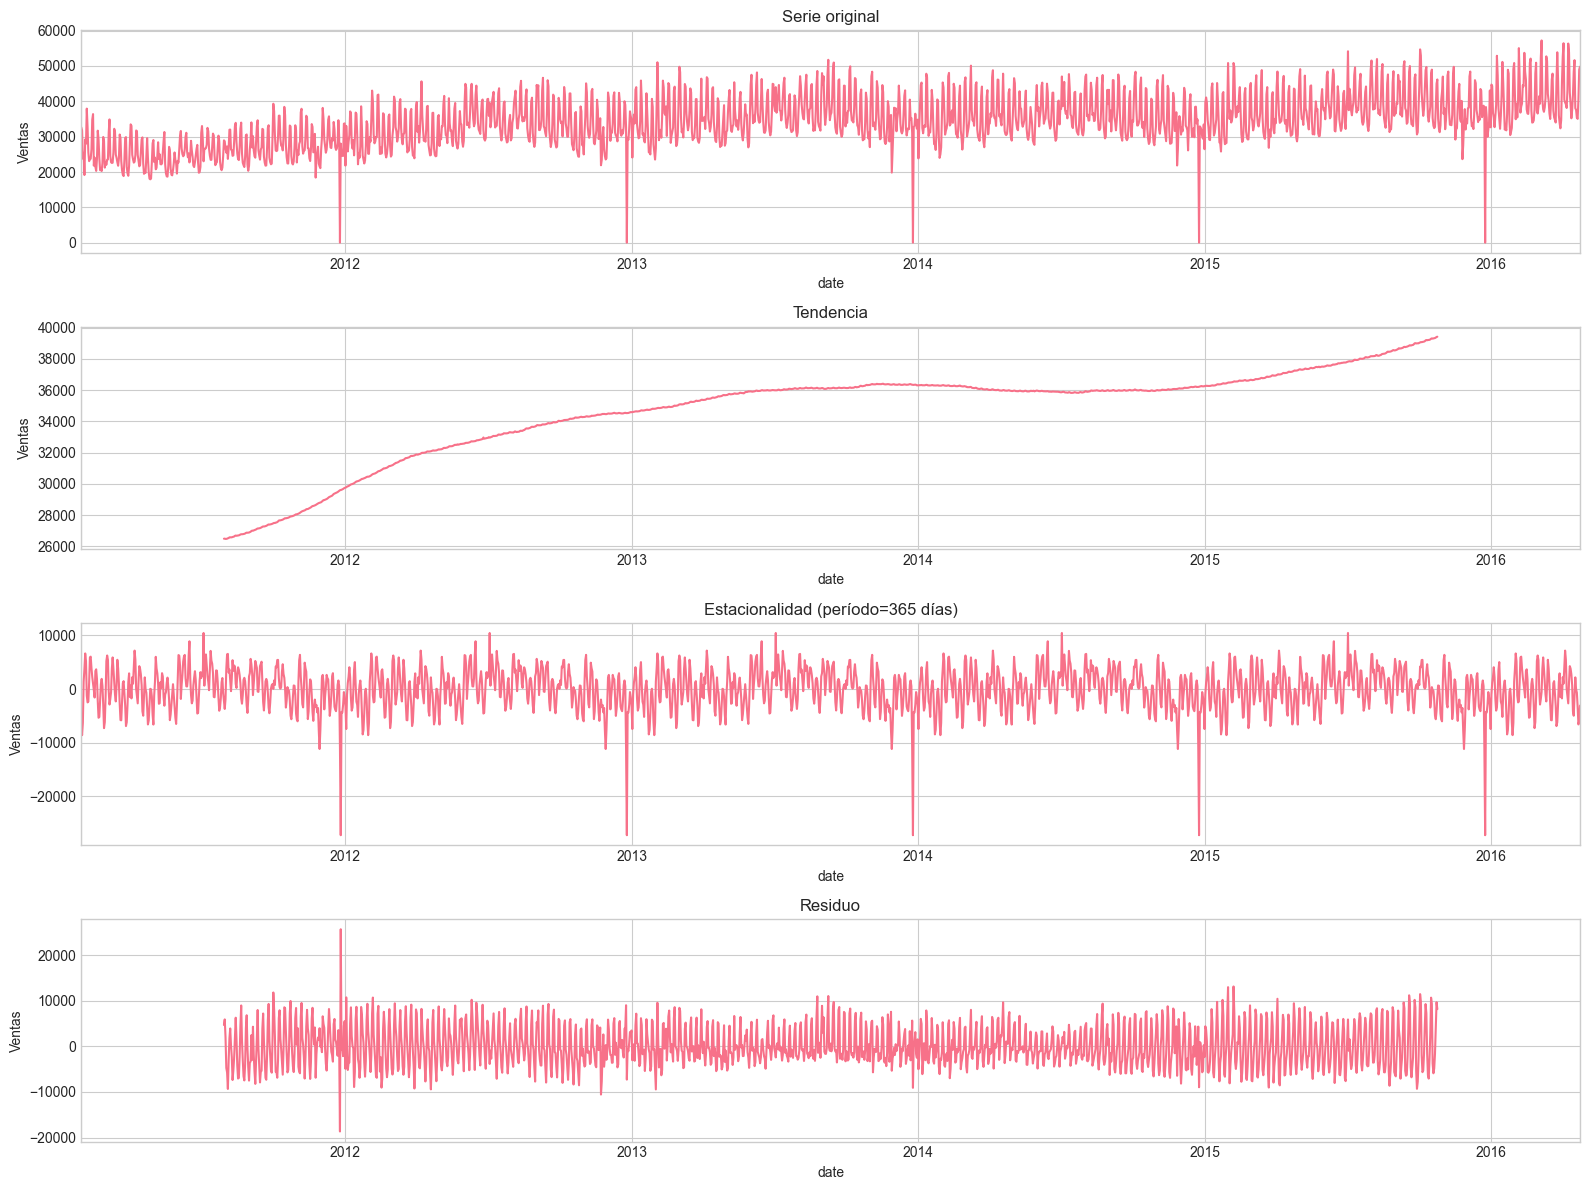

In [17]:
# Descomposición con período anual (365 días)
# Esto captura estacionalidad anual

decomposition_anual = seasonal_decompose(serie_temporal, model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(16, 12))

decomposition_anual.observed.plot(ax=axes[0], title='Serie original')
axes[0].set_ylabel('Ventas')

decomposition_anual.trend.plot(ax=axes[1], title='Tendencia')
axes[1].set_ylabel('Ventas')

decomposition_anual.seasonal.plot(ax=axes[2], title='Estacionalidad (período=365 días)')
axes[2].set_ylabel('Ventas')

decomposition_anual.resid.plot(ax=axes[3], title='Residuo')
axes[3].set_ylabel('Ventas')

plt.tight_layout()
plt.show()

In [18]:
# Cuantificar la varianza explicada por cada componente
print("="*60)
print("VARIANZA EXPLICADA POR CADA COMPONENTE (período=7)")
print("="*60)

var_original = serie_temporal.var()
var_tendencia = decomposition_semanal.trend.var()
var_estacional = decomposition_semanal.seasonal.var()
var_residuo = decomposition_semanal.resid.var()

print(f"Varianza original: {var_original:,.0f}")
print(f"Varianza tendencia: {var_tendencia:,.0f} ({var_tendencia/var_original*100:.1f}%)")
print(f"Varianza estacionalidad: {var_estacional:,.0f} ({var_estacional/var_original*100:.1f}%)")
print(f"Varianza residuo: {var_residuo:,.0f} ({var_residuo/var_original*100:.1f}%)")

VARIANZA EXPLICADA POR CADA COMPONENTE (período=7)
Varianza original: 53,962,323
Varianza tendencia: 24,302,159 (45.0%)
Varianza estacionalidad: 21,731,563 (40.3%)
Varianza residuo: 7,095,223 (13.1%)


## 6. Análisis de autocorrelación

La autocorrelación mide la relación entre una observación y sus valores pasados (lags). Esto nos indica:
- **ACF (Autocorrelation Function)**: correlación con lags pasados
- **PACF (Partial Autocorrelation Function)**: correlación directa con cada lag (eliminando intermedios)

Identificar lags significativos es clave para crear features de lag en el modelo.

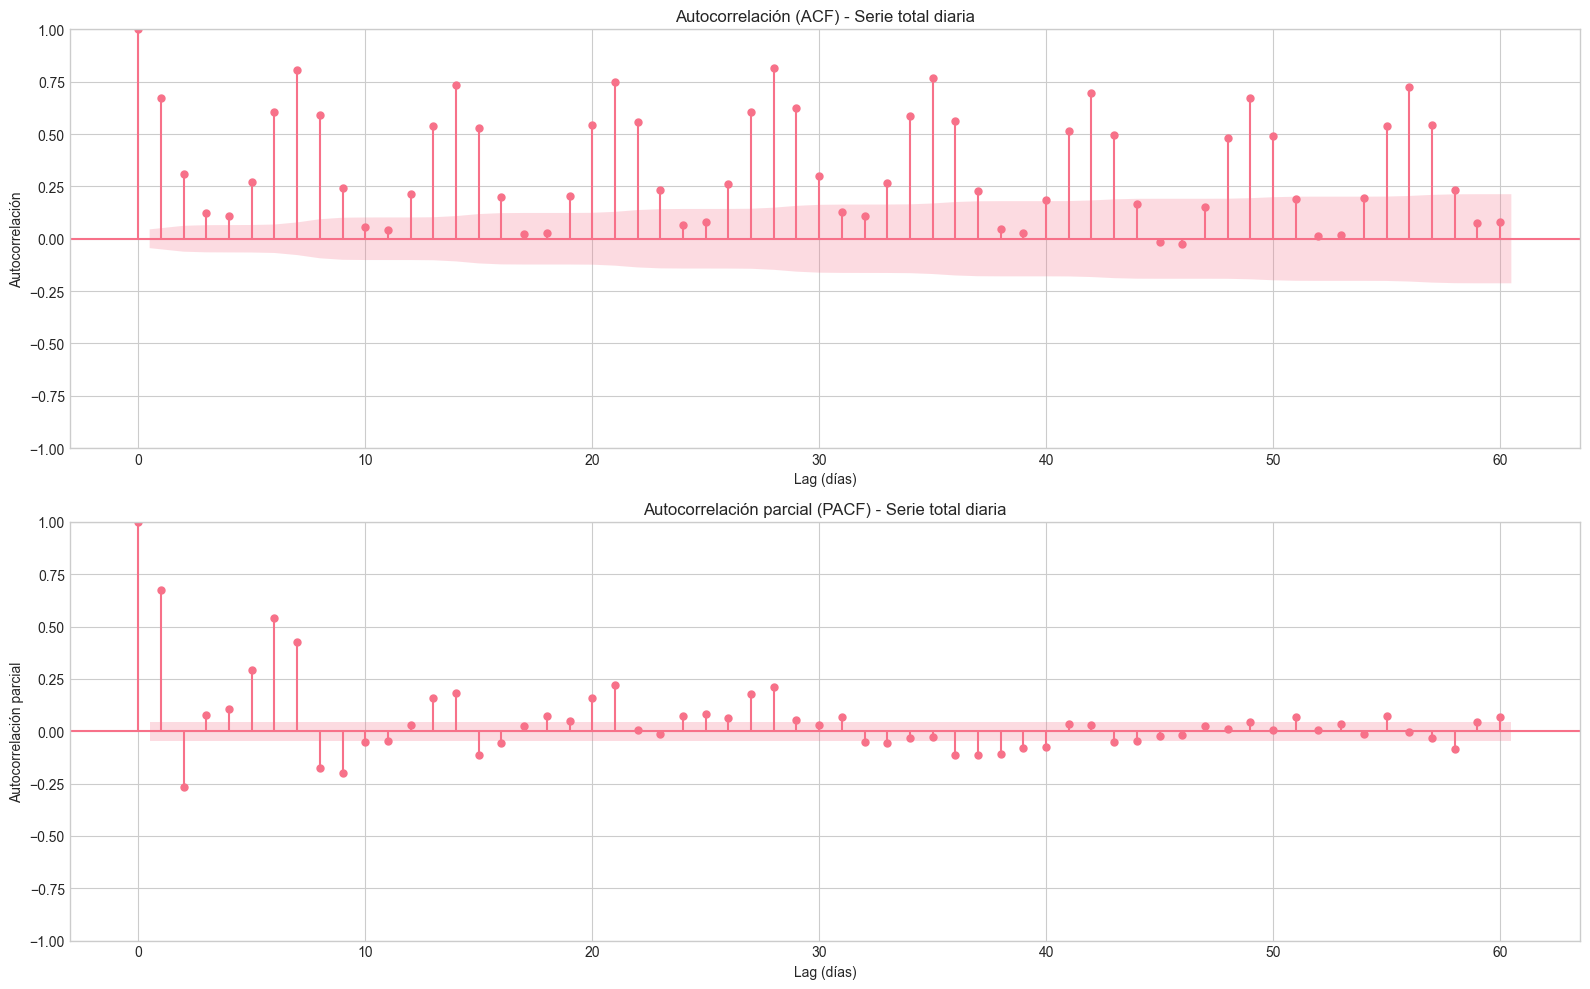

In [19]:
# ACF y PACF de la serie total
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# ACF - hasta 60 lags (2 meses)
plot_acf(serie_temporal, lags=60, ax=axes[0], title='Autocorrelación (ACF) - Serie total diaria')
axes[0].set_xlabel('Lag (días)')
axes[0].set_ylabel('Autocorrelación')

# PACF - hasta 60 lags
plot_pacf(serie_temporal, lags=60, ax=axes[1], title='Autocorrelación parcial (PACF) - Serie total diaria', method='ywm')
axes[1].set_xlabel('Lag (días)')
axes[1].set_ylabel('Autocorrelación parcial')

plt.tight_layout()
plt.show()

In [20]:
# Calcular autocorrelaciones numéricas para lags específicos
print("="*60)
print("AUTOCORRELACIONES PARA LAGS CLAVE")
print("="*60)

lags_interes = [1, 2, 3, 7, 14, 21, 28, 30, 60, 90, 365]

for lag in lags_interes:
    if lag < len(serie_temporal):
        corr = serie_temporal.autocorr(lag=lag)
        print(f"Lag {lag:3d} días: {corr:.4f}")

AUTOCORRELACIONES PARA LAGS CLAVE
Lag   1 días: 0.6742
Lag   2 días: 0.3084
Lag   3 días: 0.1234
Lag   7 días: 0.8122
Lag  14 días: 0.7444
Lag  21 días: 0.7648
Lag  28 días: 0.8403
Lag  30 días: 0.3073
Lag  60 días: 0.0887
Lag  90 días: 0.5756
Lag 365 días: 0.5862


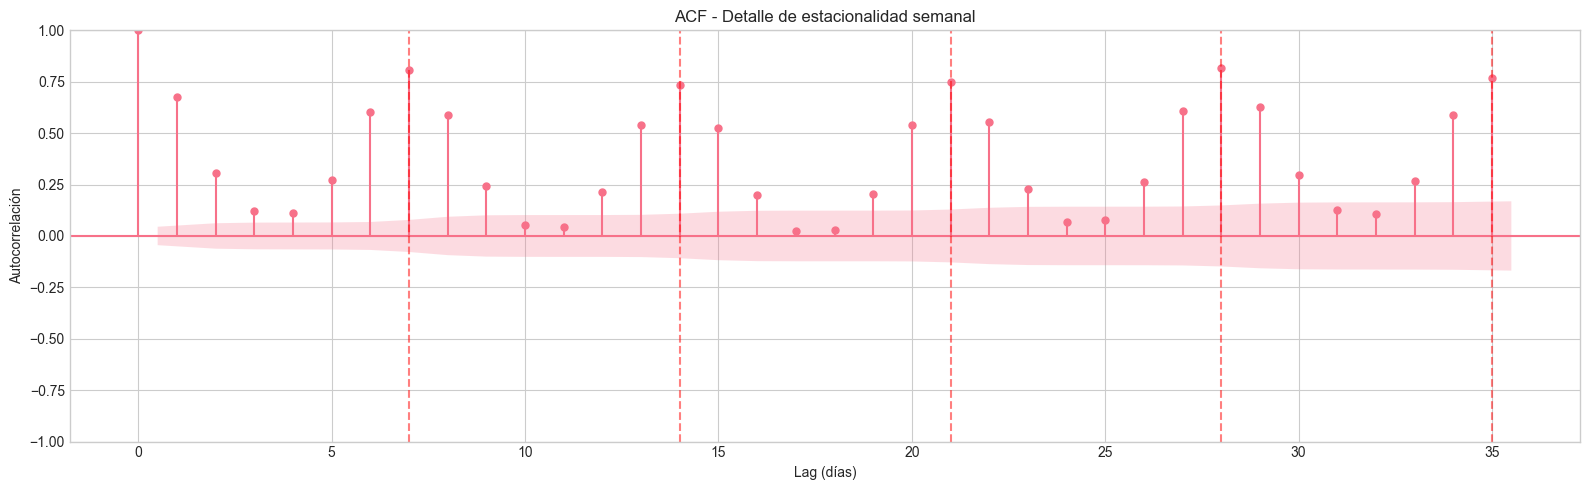

Líneas rojas = múltiplos de 7 (estacionalidad semanal)


In [21]:
# ACF para detectar estacionalidad semanal más claramente
fig, ax = plt.subplots(figsize=(16, 5))

# Mostrar hasta 35 días para ver claramente el patrón semanal
plot_acf(serie_temporal, lags=35, ax=ax, title='ACF - Detalle de estacionalidad semanal')
ax.set_xlabel('Lag (días)')
ax.set_ylabel('Autocorrelación')

# Marcar múltiplos de 7
for i in range(1, 6):
    ax.axvline(x=i*7, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("Líneas rojas = múltiplos de 7 (estacionalidad semanal)")

## 7. Efecto de variables externas

Analizamos cómo afectan a las ventas:
- Eventos especiales (festivos, comerciales)
- Día de la semana
- Precios

In [22]:
# Preparar datos con eventos
ventas_con_evento = df.groupby(['date', 'event'])['sales'].sum().reset_index()

# Separar días con y sin evento
dias_con_evento = df[df['event'].notna()].groupby('date')['sales'].sum()
dias_sin_evento = df[df['event'].isna()].groupby('date')['sales'].sum()

print("="*60)
print("COMPARACIÓN: DÍAS CON EVENTO VS SIN EVENTO")
print("="*60)
print(f"Días con evento: {len(dias_con_evento)}")
print(f"Días sin evento: {len(dias_sin_evento)}")
print(f"\nVentas promedio con evento: {dias_con_evento.mean():,.0f}")
print(f"Ventas promedio sin evento: {dias_sin_evento.mean():,.0f}")
print(f"Diferencia: {((dias_con_evento.mean() / dias_sin_evento.mean()) - 1) * 100:.1f}%")

COMPARACIÓN: DÍAS CON EVENTO VS SIN EVENTO
Días con evento: 98
Días sin evento: 1815

Ventas promedio con evento: 31,906
Ventas promedio sin evento: 34,473
Diferencia: -7.4%


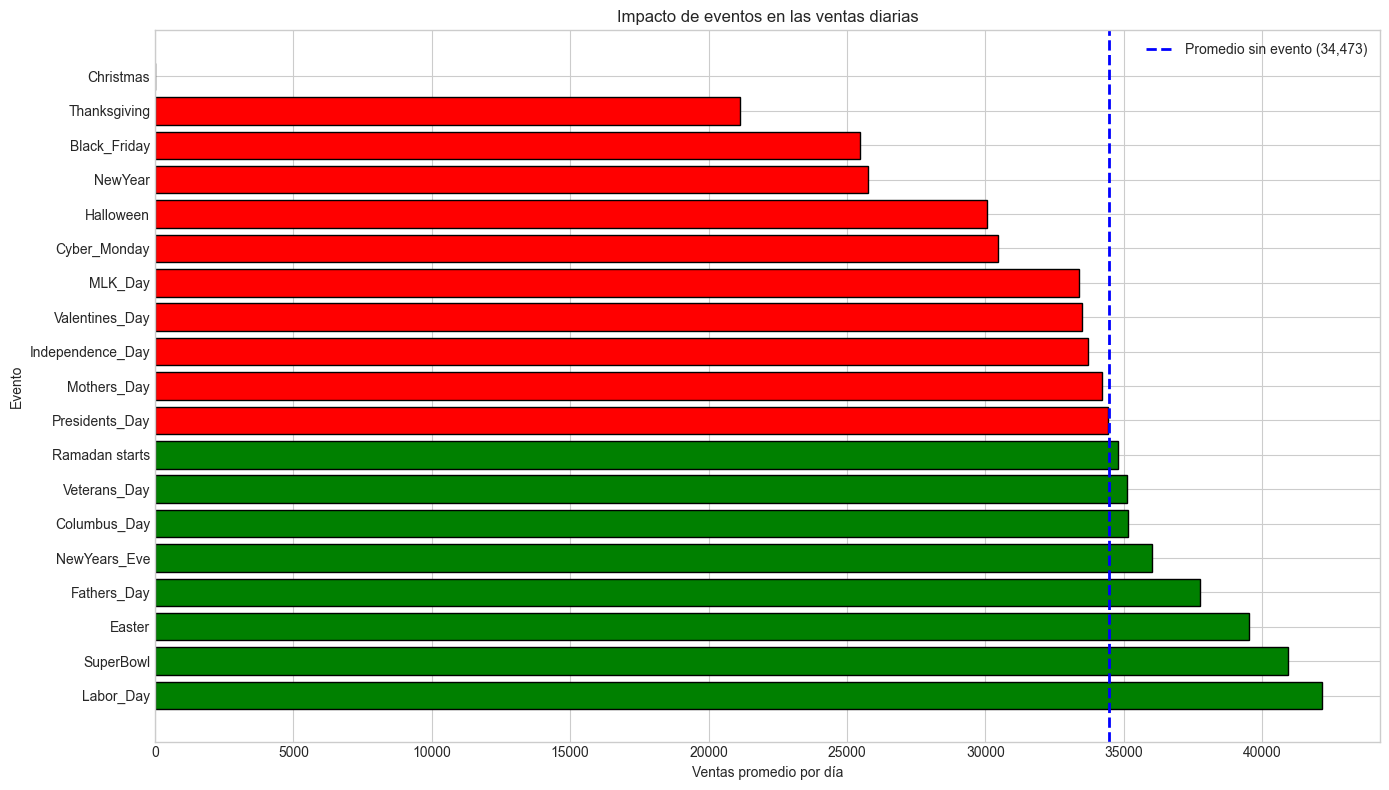


Detalle de eventos (ordenado por ventas promedio por día):
                  dias  ventas_promedio_por_dia
event                                          
Labor_Day            5                 42155.00
SuperBowl            6                 40924.00
Easter               5                 39518.00
Fathers_Day          5                 37748.00
NewYears_Eve         5                 36021.00
Columbus_Day         5                 35165.00
Veterans_Day         5                 35119.00
Ramadan starts       5                 34780.00
Presidents_Day       6                 34446.00
Mothers_Day          5                 34211.00
Independence_Day     5                 33711.00
Valentines_Day       6                 33496.00
MLK_Day              5                 33379.00
Cyber_Monday         5                 30452.00
Halloween            5                 30059.00
NewYear              5                 25768.00
Black_Friday         5                 25486.00
Thanksgiving         5      

In [23]:
# Efecto de cada tipo de evento
eventos_ventas = df[df['event'].notna()].groupby('event')['sales'].agg(['sum', 'mean', 'count'])
eventos_ventas.columns = ['ventas_totales', 'ventas_promedio_por_registro', 'num_registros']
eventos_ventas['dias'] = df[df['event'].notna()].groupby('event')['date'].nunique()
eventos_ventas['ventas_promedio_por_dia'] = eventos_ventas['ventas_totales'] / eventos_ventas['dias']
eventos_ventas = eventos_ventas.sort_values('ventas_promedio_por_dia', ascending=False)

# Visualización
fig, ax = plt.subplots(figsize=(14, 8))

colores = ['green' if x > dias_sin_evento.mean() else 'red' for x in eventos_ventas['ventas_promedio_por_dia']]
bars = ax.barh(eventos_ventas.index, eventos_ventas['ventas_promedio_por_dia'], color=colores, edgecolor='black')
ax.axvline(x=dias_sin_evento.mean(), color='blue', linestyle='--', linewidth=2, label=f'Promedio sin evento ({dias_sin_evento.mean():,.0f})')
ax.set_xlabel('Ventas promedio por día')
ax.set_ylabel('Evento')
ax.set_title('Impacto de eventos en las ventas diarias')
ax.legend()

plt.tight_layout()
plt.show()

print("\nDetalle de eventos (ordenado por ventas promedio por día):")
print(eventos_ventas[['dias', 'ventas_promedio_por_dia']].round(0))

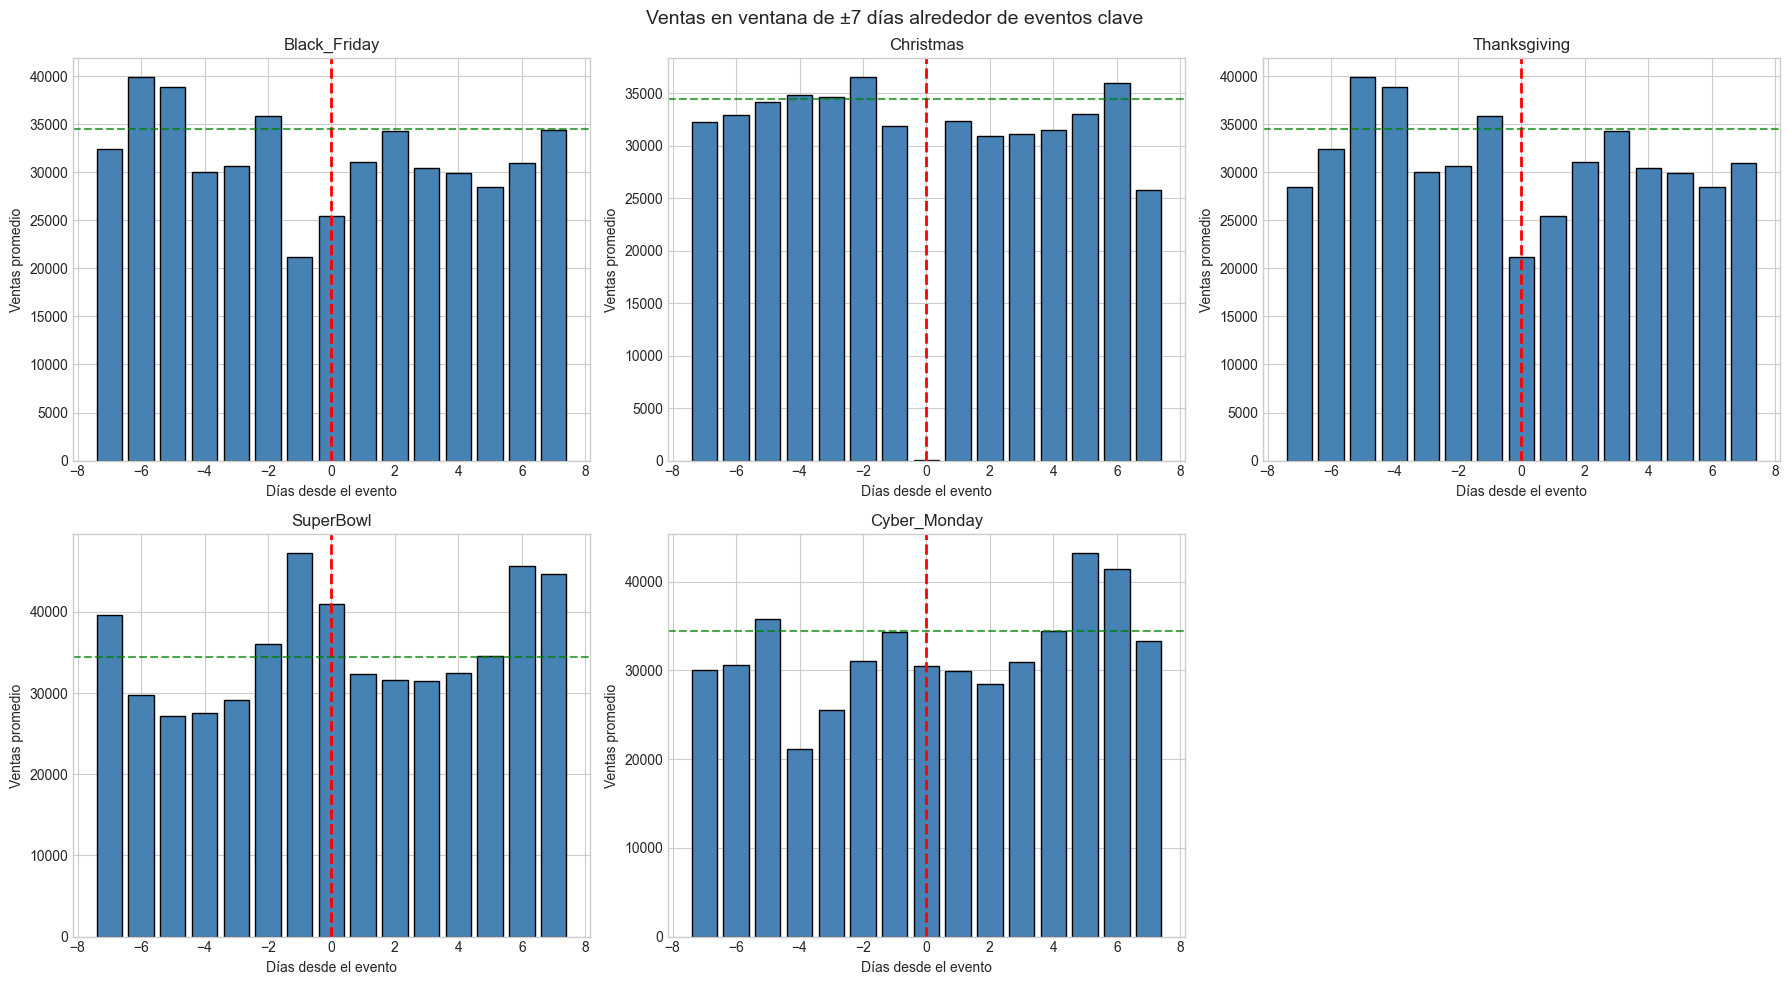

In [24]:
# Análisis de días previos y posteriores a eventos clave
# Seleccionamos algunos eventos importantes

eventos_clave = ['Black_Friday', 'Christmas', 'Thanksgiving', 'SuperBowl', 'Cyber_Monday']

# Crear dataset con días antes/después de eventos
df_eventos = df[['date', 'event', 'sales']].drop_duplicates()
ventas_por_fecha = df.groupby('date')['sales'].sum().reset_index()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, evento in enumerate(eventos_clave):
    if i >= len(axes):
        break
    
    # Fechas del evento
    fechas_evento = df[df['event'] == evento]['date'].unique()
    
    # Para cada fecha del evento, obtener ventana de -7 a +7 días
    ventanas = []
    for fecha in fechas_evento:
        for delta in range(-7, 8):
            fecha_delta = fecha + pd.Timedelta(days=delta)
            if fecha_delta in ventas_por_fecha['date'].values:
                ventas = ventas_por_fecha[ventas_por_fecha['date'] == fecha_delta]['sales'].values[0]
                ventanas.append({'delta': delta, 'sales': ventas})
    
    df_ventana = pd.DataFrame(ventanas)
    promedio_por_delta = df_ventana.groupby('delta')['sales'].mean()
    
    axes[i].bar(promedio_por_delta.index, promedio_por_delta.values, color='steelblue', edgecolor='black')
    axes[i].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[i].axhline(y=dias_sin_evento.mean(), color='green', linestyle='--', alpha=0.7)
    axes[i].set_xlabel('Días desde el evento')
    axes[i].set_ylabel('Ventas promedio')
    axes[i].set_title(f'{evento}')

# Ocultar subplot vacío si hay
if len(eventos_clave) < len(axes):
    axes[-1].axis('off')

plt.suptitle('Ventas en ventana de ±7 días alrededor de eventos clave', fontsize=14)
plt.tight_layout()
plt.show()

In [25]:
# Efecto del precio en las ventas
# Analizamos correlación precio-ventas por categoría

print("="*60)
print("CORRELACIÓN PRECIO-VENTAS POR CATEGORÍA")
print("="*60)

# Filtrar registros con precio válido
df_con_precio = df[df['sell_price'].notna()].copy()

for categoria in df_con_precio['category'].unique():
    subset = df_con_precio[df_con_precio['category'] == categoria]
    correlacion = subset['sell_price'].corr(subset['sales'])
    print(f"{categoria}: {correlacion:.4f}")

# Correlación global
correlacion_global = df_con_precio['sell_price'].corr(df_con_precio['sales'])
print(f"\nCorrelación global: {correlacion_global:.4f}")

CORRELACIÓN PRECIO-VENTAS POR CATEGORÍA
ACCESORIES: -0.1045
HOME_&_GARDEN: -0.1870
SUPERMARKET: -0.1432

Correlación global: -0.1511


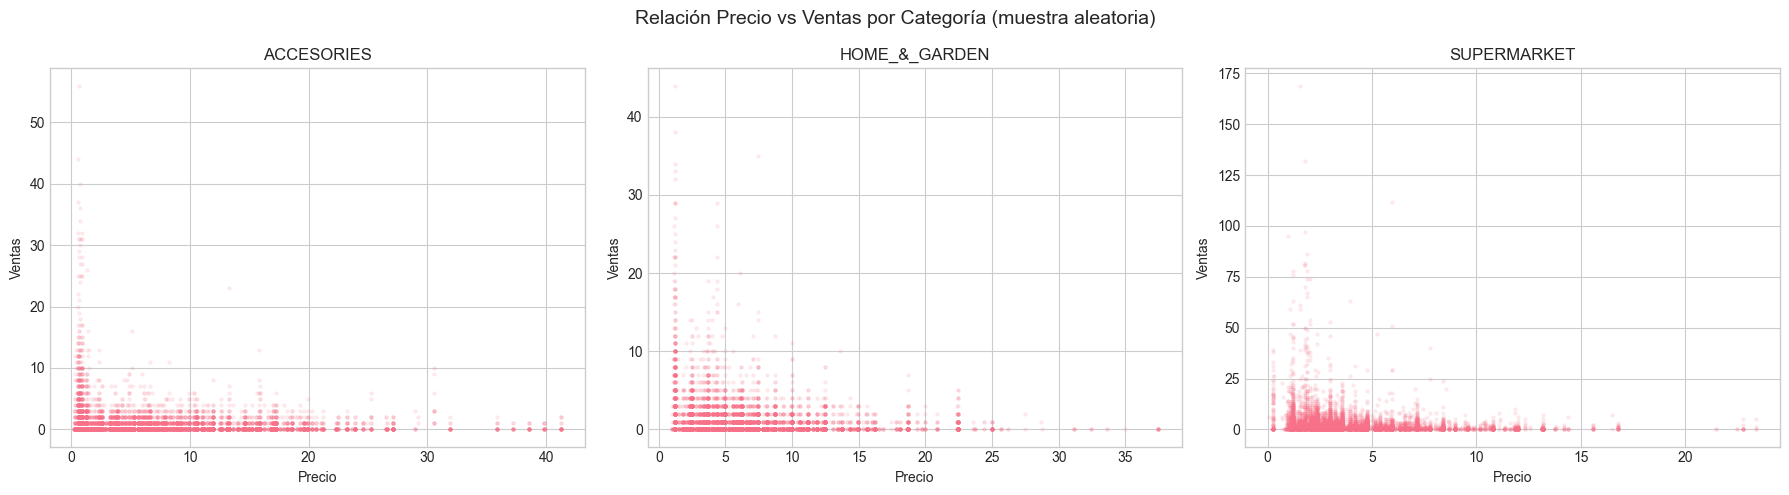

In [26]:
# Visualización precio vs ventas por categoría
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, categoria in enumerate(df_con_precio['category'].unique()):
    subset = df_con_precio[df_con_precio['category'] == categoria].sample(n=min(10000, len(df_con_precio[df_con_precio['category'] == categoria])))
    axes[i].scatter(subset['sell_price'], subset['sales'], alpha=0.1, s=5)
    axes[i].set_xlabel('Precio')
    axes[i].set_ylabel('Ventas')
    axes[i].set_title(f'{categoria}')

plt.suptitle('Relación Precio vs Ventas por Categoría (muestra aleatoria)', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Análisis por segmentos

Verificamos si los patrones temporales son consistentes entre diferentes segmentos (regiones, categorías, tiendas) o si cada segmento tiene comportamientos distintos.

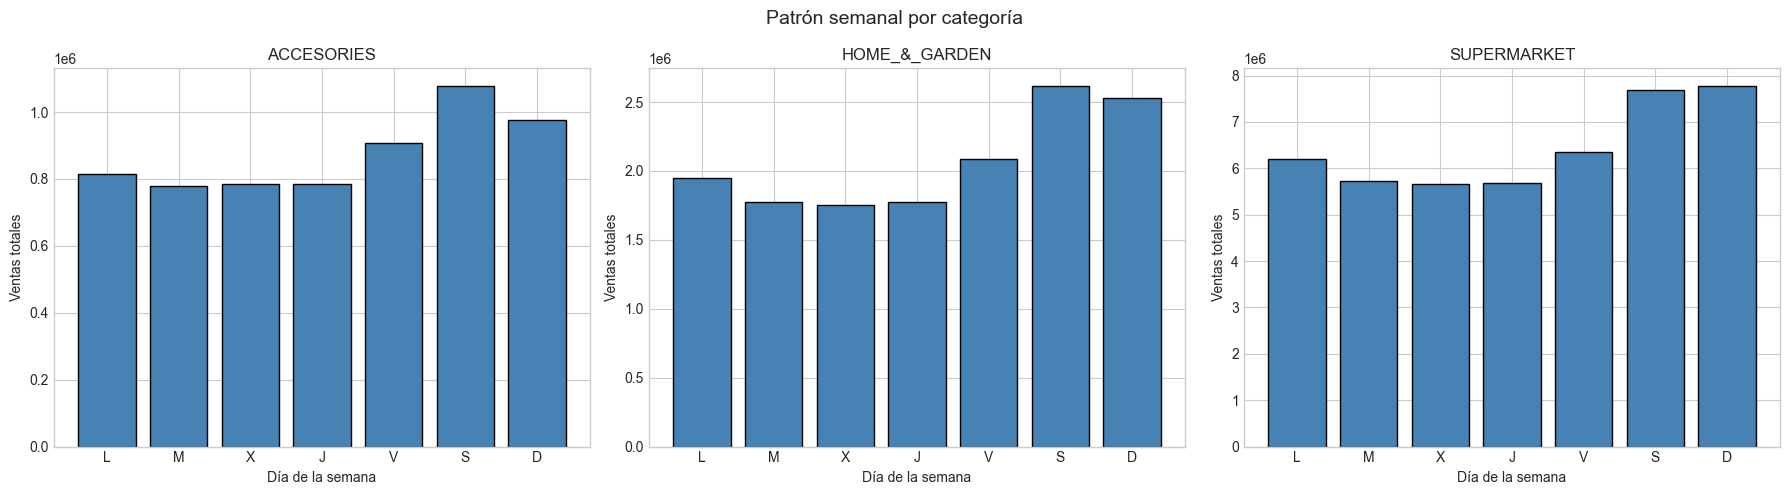

In [28]:
# Patrón semanal por categoría
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, categoria in enumerate(df['category'].unique()):
    subset = df[df['category'] == categoria]
    ventas_por_dia_cat = subset.groupby(subset['date'].dt.day_name())['sales'].sum()
    ventas_por_dia_cat = ventas_por_dia_cat.reindex(dias_orden)
    
    axes[i].bar(range(7), ventas_por_dia_cat.values, color='steelblue', edgecolor='black')
    axes[i].set_xticks(range(7))
    axes[i].set_xticklabels(['L', 'M', 'X', 'J', 'V', 'S', 'D'])
    axes[i].set_xlabel('Día de la semana')
    axes[i].set_ylabel('Ventas totales')
    axes[i].set_title(f'{categoria}')

plt.suptitle('Patrón semanal por categoría', fontsize=14)
plt.tight_layout()
plt.show()

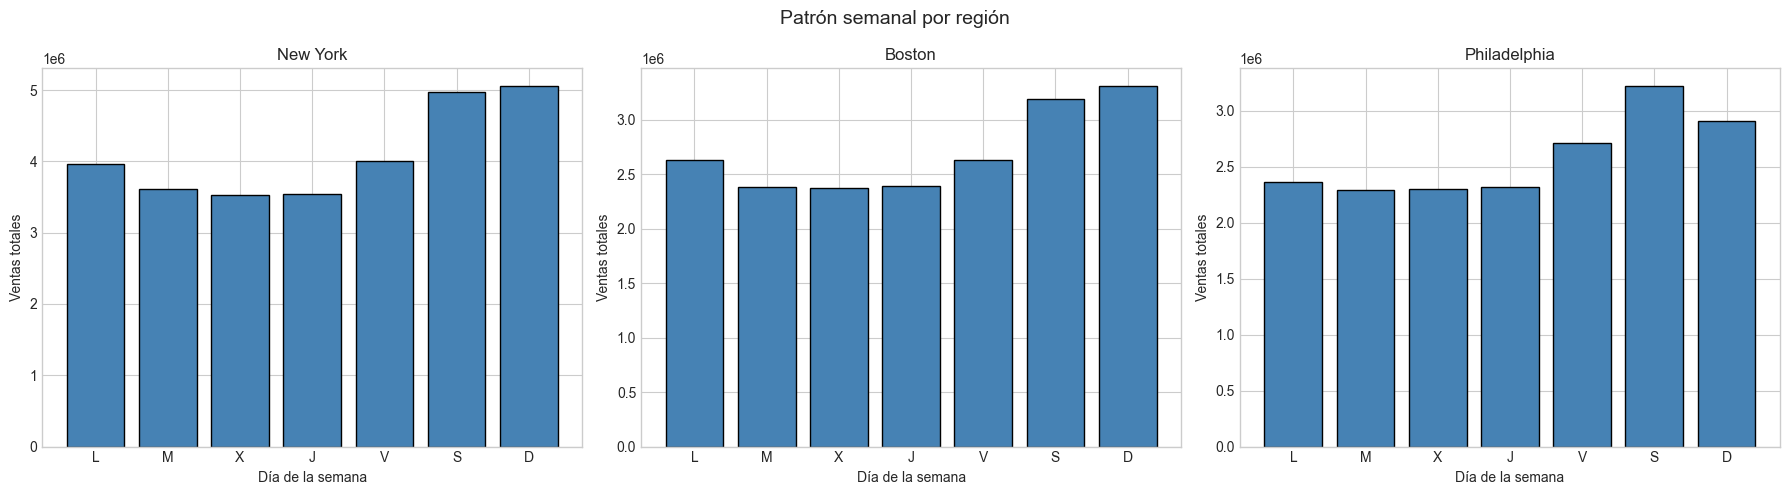

In [29]:
# Patrón semanal por región
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, region in enumerate(df['region'].unique()):
    subset = df[df['region'] == region]
    ventas_por_dia_reg = subset.groupby(subset['date'].dt.day_name())['sales'].sum()
    ventas_por_dia_reg = ventas_por_dia_reg.reindex(dias_orden)
    
    axes[i].bar(range(7), ventas_por_dia_reg.values, color='steelblue', edgecolor='black')
    axes[i].set_xticks(range(7))
    axes[i].set_xticklabels(['L', 'M', 'X', 'J', 'V', 'S', 'D'])
    axes[i].set_xlabel('Día de la semana')
    axes[i].set_ylabel('Ventas totales')
    axes[i].set_title(f'{region}')

plt.suptitle('Patrón semanal por región', fontsize=14)
plt.tight_layout()
plt.show()

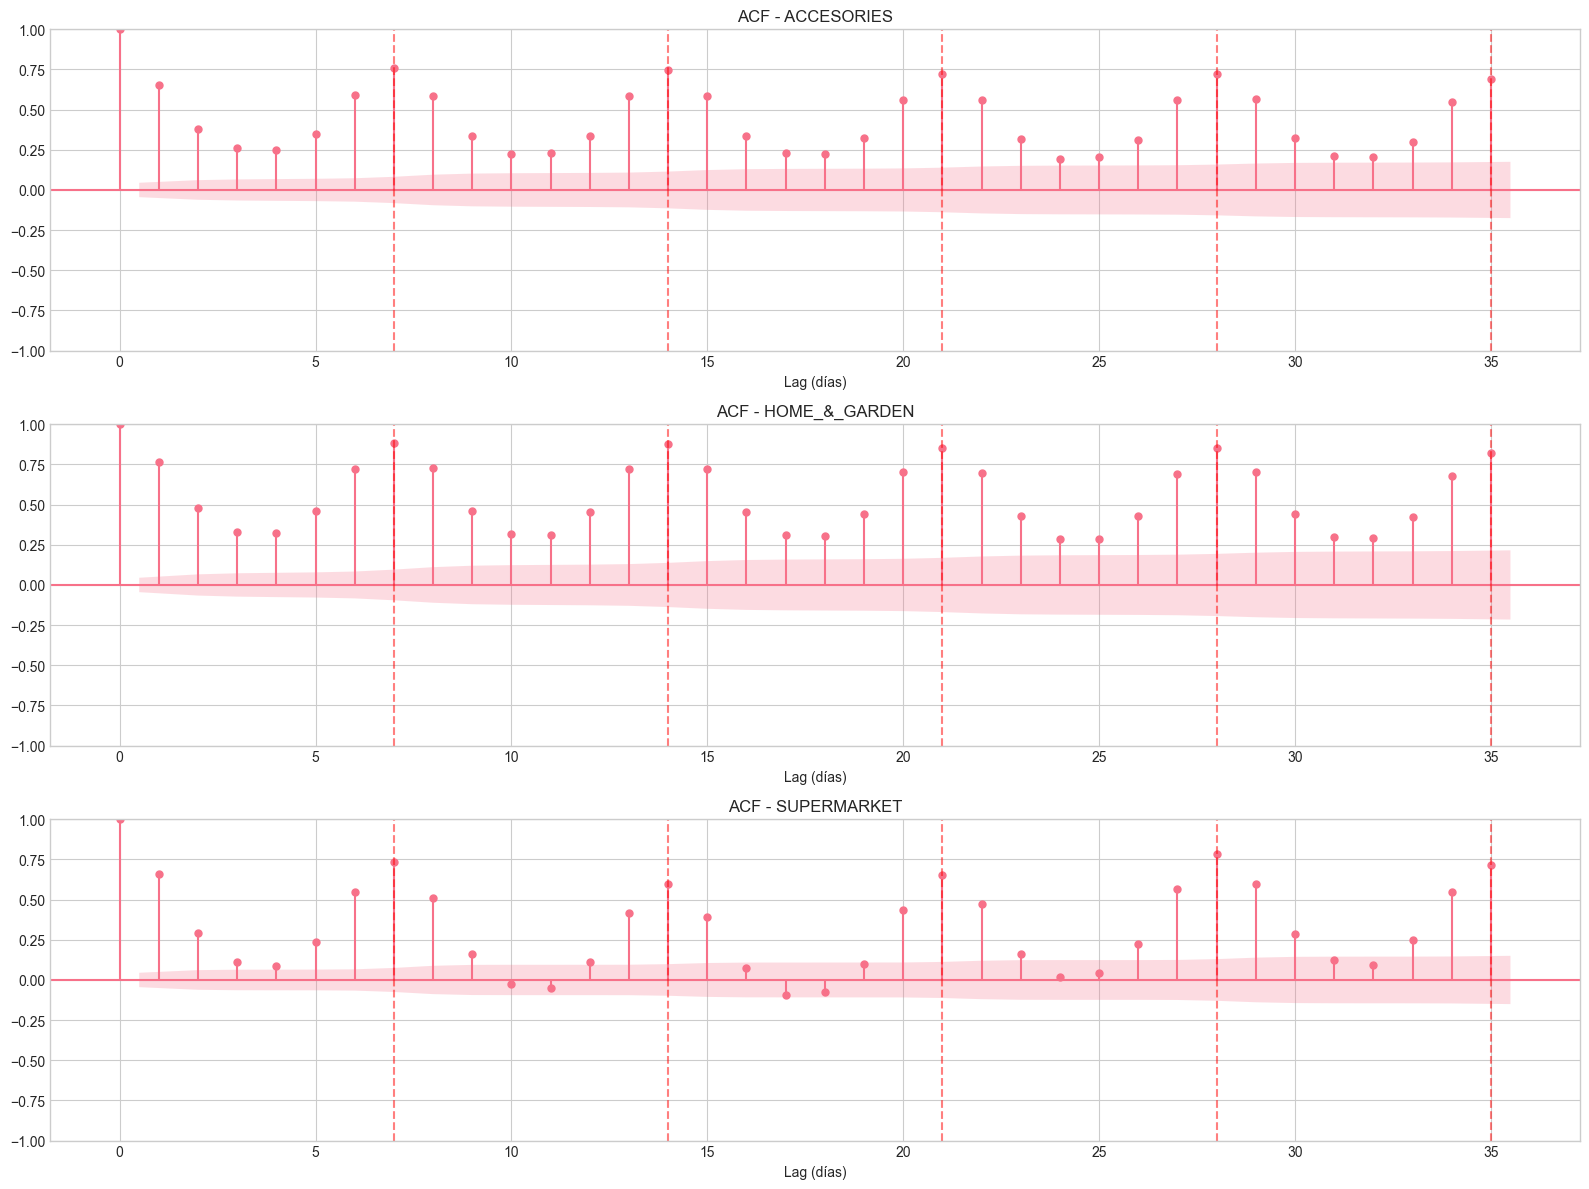

In [30]:
# Comparar ACF entre categorías
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

for i, categoria in enumerate(df['category'].unique()):
    subset = df[df['category'] == categoria].groupby('date')['sales'].sum()
    plot_acf(subset, lags=35, ax=axes[i], title=f'ACF - {categoria}')
    axes[i].set_xlabel('Lag (días)')
    # Marcar múltiplos de 7
    for j in range(1, 6):
        axes[i].axvline(x=j*7, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 9. Identificación de anomalías

Detectamos fechas con ventas atípicamente altas o bajas que podrían requerir tratamiento especial en el modelo.

In [32]:
# Detectar outliers usando IQR
Q1 = ventas_diarias['sales'].quantile(0.25)
Q3 = ventas_diarias['sales'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = ventas_diarias[(ventas_diarias['sales'] < limite_inferior) | (ventas_diarias['sales'] > limite_superior)]

print("="*60)
print("DETECCIÓN DE OUTLIERS (método IQR)")
print("="*60)
print(f"Q1: {Q1:,.0f}")
print(f"Q3: {Q3:,.0f}")
print(f"IQR: {IQR:,.0f}")
print(f"Límite inferior: {limite_inferior:,.0f}")
print(f"Límite superior: {limite_superior:,.0f}")
print(f"\nOutliers detectados: {len(outliers)} días ({len(outliers)/len(ventas_diarias)*100:.1f}%)")

DETECCIÓN DE OUTLIERS (método IQR)
Q1: 29,654
Q3: 38,689
IQR: 9,035
Límite inferior: 16,102
Límite superior: 52,242

Outliers detectados: 19 días (1.0%)


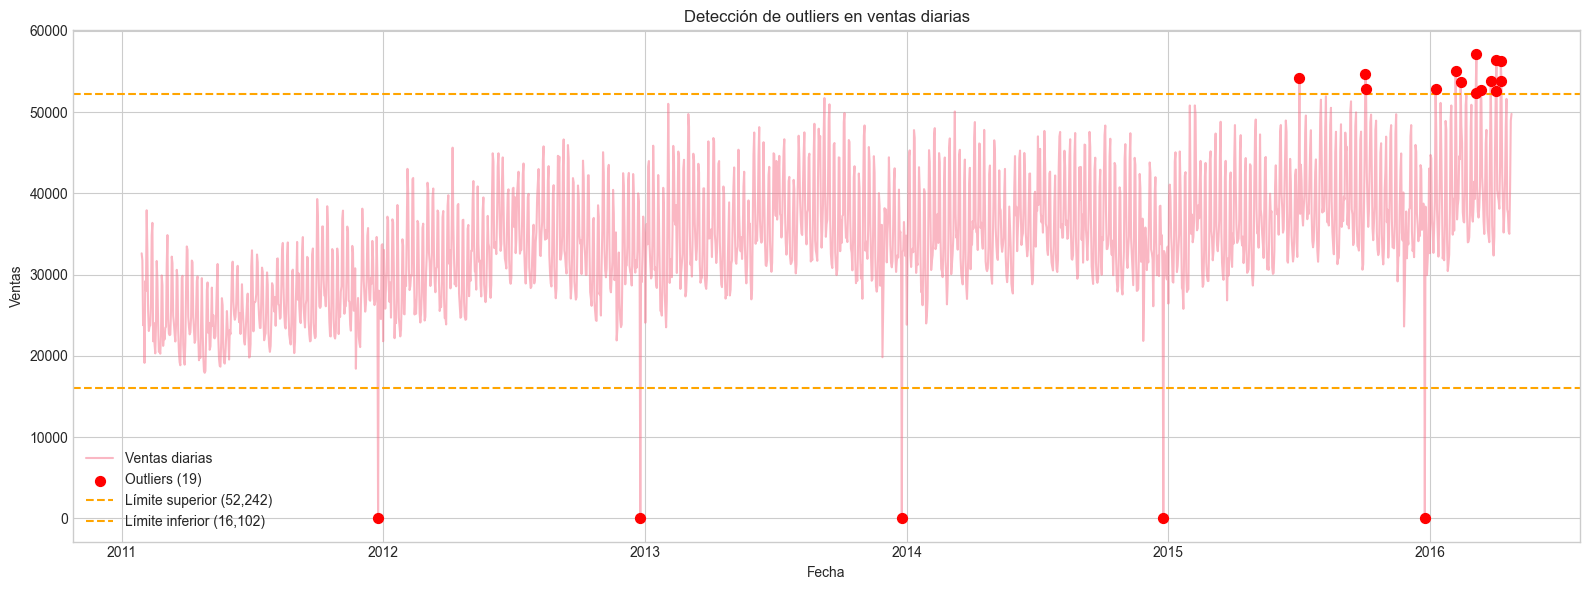

In [33]:
# Visualizar outliers
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(ventas_diarias['date'], ventas_diarias['sales'], alpha=0.5, label='Ventas diarias')
ax.scatter(outliers['date'], outliers['sales'], color='red', s=50, label=f'Outliers ({len(outliers)})', zorder=5)
ax.axhline(y=limite_superior, color='orange', linestyle='--', label=f'Límite superior ({limite_superior:,.0f})')
ax.axhline(y=limite_inferior, color='orange', linestyle='--', label=f'Límite inferior ({limite_inferior:,.0f})')

ax.set_xlabel('Fecha')
ax.set_ylabel('Ventas')
ax.set_title('Detección de outliers en ventas diarias')
ax.legend()
plt.tight_layout()
plt.show()

In [34]:
# Analizar outliers: ¿están asociados a eventos?
print("="*60)
print("ANÁLISIS DE OUTLIERS")
print("="*60)

# Outliers por debajo del límite
outliers_bajos = ventas_diarias[ventas_diarias['sales'] < limite_inferior].copy()
print(f"\nOutliers bajos (ventas < {limite_inferior:,.0f}): {len(outliers_bajos)}")

if len(outliers_bajos) > 0:
    # Obtener eventos para esas fechas
    outliers_bajos_con_evento = df[df['date'].isin(outliers_bajos['date'])][['date', 'event']].drop_duplicates()
    outliers_bajos = outliers_bajos.merge(outliers_bajos_con_evento, on='date', how='left')
    print(outliers_bajos[['date', 'sales', 'dayofweek_name', 'event']].sort_values('sales').head(20))

# Outliers por encima del límite
outliers_altos = ventas_diarias[ventas_diarias['sales'] > limite_superior].copy()
print(f"\nOutliers altos (ventas > {limite_superior:,.0f}): {len(outliers_altos)}")

if len(outliers_altos) > 0:
    outliers_altos_con_evento = df[df['date'].isin(outliers_altos['date'])][['date', 'event']].drop_duplicates()
    outliers_altos = outliers_altos.merge(outliers_altos_con_evento, on='date', how='left')
    print(outliers_altos[['date', 'sales', 'dayofweek_name', 'event']].sort_values('sales', ascending=False).head(20))

ANÁLISIS DE OUTLIERS

Outliers bajos (ventas < 16,102): 5
        date  sales dayofweek_name      event
1 2012-12-25     11        Tuesday  Christmas
0 2011-12-25     13         Sunday  Christmas
4 2015-12-25     14         Friday  Christmas
2 2013-12-25     20      Wednesday  Christmas
3 2014-12-25     20       Thursday  Christmas

Outliers altos (ventas > 52,242): 14
         date  sales dayofweek_name event
7  2016-03-06  57218         Sunday   NaN
11 2016-04-03  56425         Sunday   NaN
12 2016-04-09  56340       Saturday   NaN
4  2016-02-06  55040       Saturday   NaN
1  2015-10-03  54687       Saturday   NaN
0  2015-07-03  54154         Friday   NaN
9  2016-03-26  53863       Saturday   NaN
13 2016-04-10  53856         Sunday   NaN
5  2016-02-13  53715       Saturday   NaN
2  2015-10-04  52895         Sunday   NaN
3  2016-01-09  52880       Saturday   NaN
8  2016-03-12  52711       Saturday   NaN
10 2016-04-02  52672       Saturday   NaN
6  2016-03-05  52322       Saturday   Na

In [35]:
# Test de estacionariedad (Augmented Dickey-Fuller)
print("="*60)
print("TEST DE ESTACIONARIEDAD (Augmented Dickey-Fuller)")
print("="*60)

resultado_adf = adfuller(serie_temporal, autolag='AIC')

print(f"Estadístico ADF: {resultado_adf[0]:.4f}")
print(f"P-valor: {resultado_adf[1]:.4f}")
print(f"Lags usados: {resultado_adf[2]}")
print(f"Observaciones: {resultado_adf[3]}")
print("\nValores críticos:")
for key, value in resultado_adf[4].items():
    print(f"  {key}: {value:.4f}")

if resultado_adf[1] < 0.05:
    print("\n✓ La serie ES estacionaria (p-valor < 0.05)")
else:
    print("\n✗ La serie NO es estacionaria (p-valor >= 0.05)")

TEST DE ESTACIONARIEDAD (Augmented Dickey-Fuller)
Estadístico ADF: -1.5654
P-valor: 0.5010
Lags usados: 26
Observaciones: 1886

Valores críticos:
  1%: -3.4338
  5%: -2.8631
  10%: -2.5676

✗ La serie NO es estacionaria (p-valor >= 0.05)


## 10. Conclusiones y recomendaciones para modelado

### Hallazgos principales

**Tendencia:**
- **Clara tendencia creciente**: Las ventas pasaron de ~26,000 unidades/día en 2011 a ~41,000 en 2016 (+57% en 5 años)
- Crecimiento más fuerte en 2011-2012 (+25.4%), luego se estabiliza (~5-9% anual)
- La tendencia es consistente en las 3 regiones, aunque New York crece más rápido
- SUPERMARKET lidera el crecimiento, seguido de HOME_&_GARDEN; ACCESORIES es más estable
- **La serie NO es estacionaria** (test ADF p-valor = 0.50), lo cual es importante para ARIMA

**Estacionalidad semanal (muy fuerte):**
- **Sábado y Domingo son los días top**: ~41,500 unidades vs ~30,000 en días laborables
- Diferencia sábado vs miércoles: **+38.4%**
- Patrón consistente en todas las categorías y regiones
- El heatmap muestra que el efecto fin de semana es estable durante todo el año

**Estacionalidad mensual (débil):**
- Variación entre meses es pequeña: de 32,504 (mayo) a 35,947 (agosto)
- Diferencia máxima: solo ~10%
- No hay un patrón mensual claro como en otros retailers (sin pico navideño típico)

**Estacionalidad anual:**
- Los patrones anuales son similares entre años (gráfico de comparación)
- Se repiten los mismos "valles" (Navidad) y "picos" (fines de semana de verano)
- La descomposición con período=365 muestra ciclo anual claro

**Autocorrelación (muy importante para ARIMA):**
- **Lag 7 = 0.81**: Fuerte correlación semanal (el sábado predice el siguiente sábado)
- **Lag 28 = 0.84**: Aún más fuerte correlación mensual (4 semanas)
- **Lag 1 = 0.67**: Correlación día anterior moderada
- **Lag 365 = 0.59**: Correlación anual moderada
- El ACF muestra picos claros en múltiplos de 7 (7, 14, 21, 28, 35...)
- **Implicación ARIMA**: Necesitará diferenciación estacional con período 7

**Efecto de eventos (hallazgo sorprendente):**
- **Los eventos reducen las ventas en promedio (-7.4%)** vs días normales
- **Eventos con impacto POSITIVO**: Labor Day (+22%), SuperBowl (+19%), Easter (+15%), Father's Day (+10%)
- **Eventos con impacto NEGATIVO**: Christmas (-99.9%, tiendas cerradas), Thanksgiving (-39%), Black Friday (-26%), NewYear (-25%)
- **Black Friday y Cyber Monday tienen ventas BAJAS** - contraintuitivo pero explicable: posible cierre o reducción de horario
- La ventana de ±7 días muestra que el pico de SuperBowl está en días previos/posteriores, no el día mismo

**Efecto del precio:**
- Correlación negativa débil (precio-ventas): -0.15 global
- Por categoría: ACCESORIES (-0.10), SUPERMARKET (-0.14), HOME_&_GARDEN (-0.19)
- El precio tiene poco poder predictivo directo (muchos otros factores dominan)

**Segmentos:**
- Patrón semanal es **idéntico** en las 3 categorías y 3 regiones
- El ACF por categoría muestra el mismo patrón de 7 días en todas
- **Conclusión**: Se puede usar un modelo global con features de categoría/región, no hace falta modelos separados

**Anomalías:**
- **19 outliers detectados (1%)** - muy pocos
- **5 outliers bajos**: Todos son días de Christmas (tiendas cerradas, 11-20 ventas)
- **14 outliers altos**: Mayoría en 2016, fines de semana sin evento especial
- Los outliers altos reflejan el crecimiento de tendencia + efecto fin de semana

### Recomendaciones para Feature Engineering

**Lags a incluir (ordenados por importancia):**
1. `lag_7`: Mismo día semana anterior (correlación 0.81)
2. `lag_28`: Hace 4 semanas (correlación 0.84)
3. `lag_1`: Día anterior (correlación 0.67)
4. `lag_14`: Hace 2 semanas (correlación 0.74)
5. `lag_21`: Hace 3 semanas (correlación 0.76)
6. `lag_365`: Hace 1 año (correlación 0.59)

**Features temporales:**
- `dayofweek`: Día de la semana (0-6) - **crítico**
- `is_weekend`: Binaria (sábado/domingo) - **crítico**
- `month`: Mes del año (1-12)
- `week_of_year`: Semana del año (1-52)
- `day_of_month`: Día del mes (1-31)
- `quarter`: Trimestre (1-4)
- `year`: Para capturar tendencia

**Features de eventos:**
- `is_event`: Binaria (hay evento o no)
- `event_type`: Categórica o one-hot encoding
- `days_to_christmas`: Días hasta Navidad (para capturar cierre)
- `is_store_closed`: Binaria para Christmas (ventas ~0)

**Rolling statistics:**
- `rolling_mean_7`: Media móvil 7 días
- `rolling_mean_28`: Media móvil 28 días
- `rolling_std_7`: Desviación estándar 7 días

**Tratamiento de anomalías:**
- **Christmas**: Crear variable `is_christmas` y posiblemente excluir del entrenamiento o tratar como caso especial
- **Outliers altos**: No requieren tratamiento especial, reflejan tendencia real

### Recomendaciones para ARIMA

- **Diferenciación**: La serie no es estacionaria, necesita al menos una diferenciación
- **Estacionalidad**: Período = 7 (semanal) es el más importante
- **Modelo sugerido**: SARIMA con s=7, probar (p,d,q)(P,D,Q)₇
- **Alternativa**: Dado el volumen de series (30,490), considerar modelos jerárquicos o usar ARIMA solo para series agregadas

### Siguientes pasos
1. **Notebook 04**: Análisis de temporadas (Spring Break, Summer, Back to School, Winter Holidays)
2. **Notebook 05**: Deep Dive por Eventos (especialmente Labor Day, SuperBowl, Black Friday)
3. **Notebook 06**: Feature Engineering completo
4. **Notebook 07**: Clustering de productos/tiendas
5. **Notebooks 08-09**: Modelos baseline y ARIMA